In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv("titanic.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (889, 14)

Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


In [9]:
# ==========================================
# FEATURE ENGINEERING
# ==========================================

df["family_size"] = (
    df["sibsp"] + df["parch"] + 1
)

df["is_alone"] = (
    df["family_size"] == 1
).astype(int)

print("Engineered features created.")

display(
    df[
        [
            "sibsp",
            "parch",
            "family_size",
            "is_alone"
        ]
    ].head(10)
)

Engineered features created.


,sibsp,parch,family_size,is_alone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1
5,0,0,1,1
6,0,0,1,1
7,3,1,5,0
8,0,2,3,0
9,1,0,2,0


In [10]:
# ==========================================
# TARGET AND FEATURES
# ==========================================

target = "survived"

X = df.drop(columns=[target])
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget proportions:")
print(y.value_counts(normalize=True))

Feature matrix shape: (889, 15)
Target shape: (889,)

Target distribution:
survived
0    549
1    340
Name: count, dtype: int64

Target proportions:
survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64


In [11]:
# ==========================================
# TRAIN / TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining target proportions:")
print(y_train.value_counts(normalize=True))

print("\nTesting target proportions:")
print(y_test.value_counts(normalize=True))

Training rows: 711
Testing rows: 178

Training target proportions:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing target proportions:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


In [15]:
# Remove the redundant embark_town representation.
# We retain embarked as the categorical boarding-location feature.

X = df.drop(
    columns=[
        "survived",
        "alive",
        "alone",
        "class",
        "who",
        "adult_male",
        "embark_town"
    ]
)

y = df["survived"]

print("Final modeling features:")
print(X.columns.tolist())

print("\nFeature matrix shape:")
print(X.shape)

Final modeling features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'family_size', 'is_alone']

Feature matrix shape:
(889, 9)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 711
Testing rows: 178


In [17]:
# ==========================================
# FINAL LEAKAGE-SAFE PREPROCESSOR
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare",
    "family_size",
    "is_alone"
]

categorical_features = [
    "sex",
    "embarked"
]


numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Final preprocessor created successfully.")
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Final preprocessor created successfully.
Numeric features: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone']
Categorical features: ['sex', 'embarked']


In [18]:
# ==========================================
# BASELINE CLASSIFICATION MODELS
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}


pipelines = {}

for model_name, model in models.items():

    pipelines[model_name] = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )


print("Baseline pipelines created:")

for name in pipelines:
    print("-", name)

Baseline pipelines created:
- Logistic Regression
- Decision Tree
- Random Forest


In [19]:
# ==========================================
# TRAIN BASELINE MODELS
# ==========================================

for model_name, pipeline in pipelines.items():

    print(f"Training {model_name}...")

    pipeline.fit(
        X_train,
        y_train
    )

print("\nAll baseline models trained successfully.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...

All baseline models trained successfully.


In [20]:
# ==========================================
# MODEL EVALUATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report,
    RocCurveDisplay
)

import matplotlib.pyplot as plt


evaluation_results = []

for model_name, pipeline in pipelines.items():

    y_pred = pipeline.predict(X_test)

    y_proba = pipeline.predict_proba(
        X_test
    )[:, 1]

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        y_proba
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    evaluation_results.append(
        {
            "model": model_name,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "roc_auc": roc_auc
        }
    )

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    print("Confusion Matrix:")
    print(cm)


evaluation_df = pd.DataFrame(
    evaluation_results
)

print("\n===== MODEL COMPARISON =====")

display(
    evaluation_df.sort_values(
        "roc_auc",
        ascending=False
    )
)


Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       110
           1       0.80      0.71      0.75        68

    accuracy                           0.82       178
   macro avg       0.82      0.80      0.80       178
weighted avg       0.82      0.82      0.82       178

Confusion Matrix:
[[98 12]
 [20 48]]

Decision Tree

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.81      0.82       110
           1       0.70      0.72      0.71        68

    accuracy                           0.78       178
   macro avg       0.76      0.76      0.76       178
weighted avg       0.78      0.78      0.78       178

Confusion Matrix:
[[89 21]
 [19 49]]

Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       110
           1       0.74      0.71      0

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.820225,0.800000,0.705882,0.750000,0.864973
2,Random Forest,0.792135,0.738462,0.705882,0.721805,0.816511
1,Decision Tree,0.775281,0.700000,0.720588,0.710145,0.758690


<Figure size 900x700 with 0 Axes>

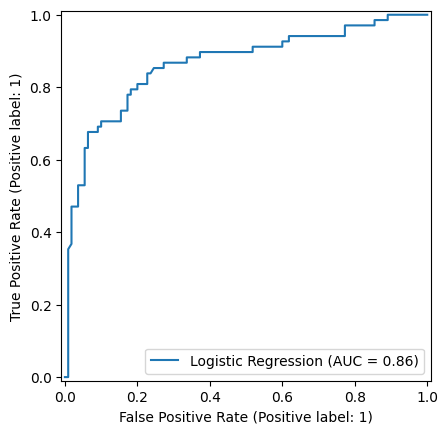

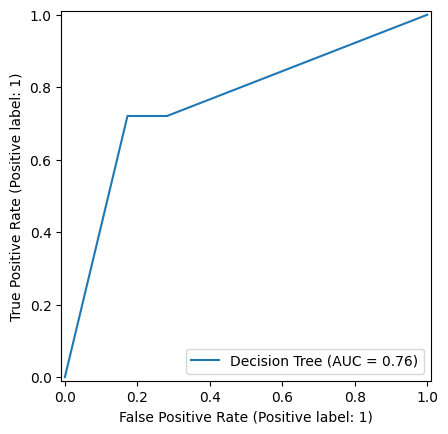

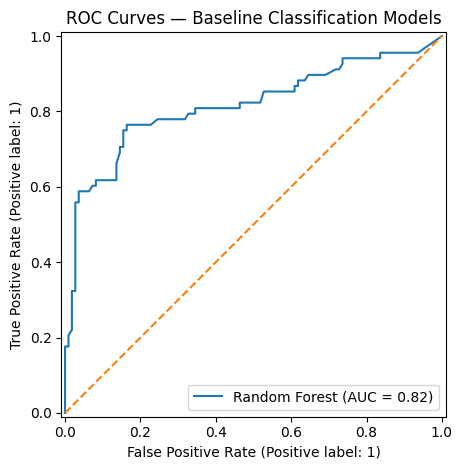

In [21]:
# ==========================================
# ROC CURVES
# ==========================================

plt.figure(figsize=(9, 7))

for model_name, pipeline in pipelines.items():

    RocCurveDisplay.from_estimator(
        pipeline,
        X_test,
        y_test,
        name=model_name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title(
    "ROC Curves — Baseline Classification Models"
)

plt.tight_layout()
plt.show()

In [23]:
%pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached imbalanced_learn-0.14.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.6-py3-none-any.whl.metadata (22 kB)
Using cached imbalanced_learn-0.14.2-py3-none-any.whl (236 kB)
Using cached sklearn_compat-0.1.6-py3-none-any.whl (22 kB)

   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalan


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\nikhi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [24]:
# ==========================================
# CLASS IMBALANCE: BASELINE VS BALANCED VS SMOTE
# ==========================================

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


# ------------------------------------------
# 1. Baseline Logistic Regression
# ------------------------------------------

baseline_lr = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)


# ------------------------------------------
# 2. Class-weighted Logistic Regression
# ------------------------------------------

balanced_lr = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)


# ------------------------------------------
# 3. SMOTE Logistic Regression
# ------------------------------------------

smote_lr = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "smote",
            SMOTE(
                random_state=42
            )
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)


imbalance_models = {
    "Baseline Logistic Regression": baseline_lr,
    "Class-Weighted Logistic Regression": balanced_lr,
    "SMOTE Logistic Regression": smote_lr
}


# ------------------------------------------
# Train
# ------------------------------------------

for name, model in imbalance_models.items():

    print(f"Training: {name}")

    model.fit(
        X_train,
        y_train
    )

print("\nAll imbalance experiments trained.")

Training: Baseline Logistic Regression
Training: Class-Weighted Logistic Regression
Training: SMOTE Logistic Regression

All imbalance experiments trained.


In [25]:
# ==========================================
# EVALUATE IMBALANCE STRATEGIES
# ==========================================

imbalance_results = []

for name, model in imbalance_models.items():

    y_pred = model.predict(X_test)

    y_proba = model.predict_proba(
        X_test
    )[:, 1]

    imbalance_results.append(
        {
            "model": name,
            "accuracy": accuracy_score(
                y_test,
                y_pred
            ),
            "precision": precision_score(
                y_test,
                y_pred
            ),
            "recall": recall_score(
                y_test,
                y_pred
            ),
            "f1": f1_score(
                y_test,
                y_pred
            ),
            "roc_auc": roc_auc_score(
                y_test,
                y_proba
            )
        }
    )


imbalance_df = pd.DataFrame(
    imbalance_results
)

display(
    imbalance_df.sort_values(
        "f1",
        ascending=False
    )
)

,model,accuracy,precision,recall,f1,roc_auc
2,SMOTE Logistic Regression,0.814607,0.746479,0.779412,0.762590,0.865775
1,Class-Weighted Logistic Regression,0.808989,0.736111,0.779412,0.757143,0.865909
0,Baseline Logistic Regression,0.820225,0.800000,0.705882,0.750000,0.864973


In [26]:
# ==========================================
# CONFUSION MATRICES
# ==========================================

for name, model in imbalance_models.items():

    y_pred = model.predict(X_test)

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(
        confusion_matrix(
            y_test,
            y_pred
        )
    )

    print(
        classification_report(
            y_test,
            y_pred
        )
    )


Baseline Logistic Regression
[[98 12]
 [20 48]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       110
           1       0.80      0.71      0.75        68

    accuracy                           0.82       178
   macro avg       0.82      0.80      0.80       178
weighted avg       0.82      0.82      0.82       178


Class-Weighted Logistic Regression
[[91 19]
 [15 53]]
              precision    recall  f1-score   support

           0       0.86      0.83      0.84       110
           1       0.74      0.78      0.76        68

    accuracy                           0.81       178
   macro avg       0.80      0.80      0.80       178
weighted avg       0.81      0.81      0.81       178


SMOTE Logistic Regression
[[92 18]
 [15 53]]
              precision    recall  f1-score   support

           0       0.86      0.84      0.85       110
           1       0.75      0.78      0.76        68

    accuracy                    

In [27]:
# ==========================================
# RANDOM FOREST HYPERPARAMETER TUNING
# ==========================================

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier


rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1,
                oob_score=True
            )
        )
    ]
)


param_grid = {
    "model__n_estimators": [
        100,
        200
    ],
    "model__max_depth": [
        None,
        5,
        10
    ],
    "model__min_samples_split": [
        2,
        5
    ],
    "model__min_samples_leaf": [
        1,
        2
    ]
}


grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True
)


print("Starting Random Forest GridSearchCV...")

grid_search.fit(
    X_train,
    y_train
)

print("\nGridSearchCV completed.")

print("\nBest parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(grid_search.best_score_)

Starting Random Forest GridSearchCV...

GridSearchCV completed.

Best parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Best cross-validation ROC-AUC:
0.8749663431599167


In [28]:
# ==========================================
# RANDOM FOREST OOB SCORE
# ==========================================

best_rf_pipeline = grid_search.best_estimator_

best_rf_model = (
    best_rf_pipeline
    .named_steps["model"]
)

print(
    "Random Forest OOB score:",
    best_rf_model.oob_score_
)

Random Forest OOB score: 0.8213783403656821


In [29]:
# ==========================================
# TUNED RANDOM FOREST TEST PERFORMANCE
# ==========================================

tuned_rf_pred = grid_search.predict(
    X_test
)

tuned_rf_proba = grid_search.predict_proba(
    X_test
)[:, 1]


tuned_rf_results = {
    "accuracy": accuracy_score(
        y_test,
        tuned_rf_pred
    ),
    "precision": precision_score(
        y_test,
        tuned_rf_pred
    ),
    "recall": recall_score(
        y_test,
        tuned_rf_pred
    ),
    "f1": f1_score(
        y_test,
        tuned_rf_pred
    ),
    "roc_auc": roc_auc_score(
        y_test,
        tuned_rf_proba
    )
}


print("\n===== TUNED RANDOM FOREST =====")

for metric, value in tuned_rf_results.items():
    print(
        f"{metric}: {value:.4f}"
    )

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        tuned_rf_pred
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        tuned_rf_pred
    )
)


===== TUNED RANDOM FOREST =====
accuracy: 0.8090
precision: 0.7833
recall: 0.6912
f1: 0.7344
roc_auc: 0.8295

Confusion Matrix:
[[97 13]
 [21 47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.69      0.73        68

    accuracy                           0.81       178
   macro avg       0.80      0.79      0.79       178
weighted avg       0.81      0.81      0.81       178



In [30]:
# ==========================================
# REGRESSION TASK
# Predict Fare
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# ------------------------------------------
# Regression features and target
# ------------------------------------------

regression_features = [
    "age",
    "pclass",
    "sibsp",
    "parch",
    "family_size",
    "is_alone"
]

X_reg = df[regression_features]
y_reg = df["fare"]

print("Regression features:")
print(regression_features)

print("\nRegression dataset shape:")
print(X_reg.shape)

Regression features:
['age', 'pclass', 'sibsp', 'parch', 'family_size', 'is_alone']

Regression dataset shape:
(889, 6)


In [31]:
# ==========================================
# REGRESSION TRAIN / TEST SPLIT
# ==========================================

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_reg_train))
print("Testing rows:", len(X_reg_test))

Training rows: 711
Testing rows: 178


In [32]:
# ==========================================
# REGRESSION PREPROCESSING
# ==========================================

regression_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


regression_models = {
    "Linear Regression": Pipeline(
        steps=[
            (
                "preprocessor",
                regression_preprocessor
            ),
            (
                "model",
                LinearRegression()
            )
        ]
    ),

    "Ridge Regression": Pipeline(
        steps=[
            (
                "preprocessor",
                regression_preprocessor
            ),
            (
                "model",
                Ridge(alpha=1.0)
            )
        ]
    )
}

In [33]:
# ==========================================
# TRAIN + EVALUATE REGRESSION MODELS
# ==========================================

regression_results = []

for model_name, model in regression_models.items():

    model.fit(
        X_reg_train,
        y_reg_train
    )

    predictions = model.predict(
        X_reg_test
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_reg_test,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_reg_test,
        predictions
    )

    r2 = r2_score(
        y_reg_test,
        predictions
    )

    n = len(y_reg_test)
    p = X_reg_test.shape[1]

    adjusted_r2 = (
        1
        -
        (
            (1 - r2) * (n - 1)
            /
            (n - p - 1)
        )
    )

    regression_results.append(
        {
            "model": model_name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
            "Adjusted_R2": adjusted_r2
        }
    )


regression_results_df = pd.DataFrame(
    regression_results
)

print("===== REGRESSION MODEL COMPARISON =====")

display(
    regression_results_df
)

===== REGRESSION MODEL COMPARISON =====


,model,RMSE,MAE,R2,Adjusted_R2
0,Linear Regression,42.553811,20.752749,0.321265,0.297450
1,Ridge Regression,42.552943,20.734601,0.321293,0.297478


In [34]:
# ==========================================
# FINAL CLASSIFICATION COMPARISON
# ==========================================

classification_comparison = pd.concat(
    [
        evaluation_df,
        imbalance_df[
            imbalance_df["model"] !=
            "Baseline Logistic Regression"
        ]
    ],
    ignore_index=True
)

# Add tuned Random Forest
classification_comparison = pd.concat(
    [
        classification_comparison,
        pd.DataFrame(
            [
                {
                    "model": "Tuned Random Forest",
                    "accuracy": tuned_rf_results["accuracy"],
                    "precision": tuned_rf_results["precision"],
                    "recall": tuned_rf_results["recall"],
                    "f1": tuned_rf_results["f1"],
                    "roc_auc": tuned_rf_results["roc_auc"]
                }
            ]
        )
    ],
    ignore_index=True
)

display(
    classification_comparison.sort_values(
        "roc_auc",
        ascending=False
    ).reset_index(drop=True)
)

,model,accuracy,precision,recall,f1,roc_auc
0,Class-Weighted Logistic Regression,0.808989,0.736111,0.779412,0.757143,0.865909
1,SMOTE Logistic Regression,0.814607,0.746479,0.779412,0.762590,0.865775
2,Logistic Regression,0.820225,0.800000,0.705882,0.750000,0.864973
3,Tuned Random Forest,0.808989,0.783333,0.691176,0.734375,0.829545
4,Random Forest,0.792135,0.738462,0.705882,0.721805,0.816511
5,Decision Tree,0.775281,0.700000,0.720588,0.710145,0.758690


In [35]:
# ==========================================
# LOGISTIC REGRESSION FEATURE INTERPRETATION
# ==========================================

final_lr = pipelines["Logistic Regression"]

fitted_preprocessor = (
    final_lr
    .named_steps["preprocessor"]
)

lr_model = (
    final_lr
    .named_steps["model"]
)

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

coefficients = lr_model.coef_[0]

coefficient_df = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": coefficients,
        "absolute_coefficient": np.abs(
            coefficients
        )
    }
).sort_values(
    "absolute_coefficient",
    ascending=False
)

print("===== LOGISTIC REGRESSION COEFFICIENTS =====")

display(
    coefficient_df
)

===== LOGISTIC REGRESSION COEFFICIENTS =====


,feature,coefficient,absolute_coefficient
8,categorical__sex_male,-1.287785,1.287785
7,categorical__sex_female,1.246452,1.246452
0,numeric__pclass,-0.827567,0.827567
1,numeric__age,-0.453254,0.453254
10,categorical__embarked_Q,0.334407,0.334407
6,numeric__is_alone,-0.330959,0.330959
11,categorical__embarked_S,-0.313897,0.313897
2,numeric__sibsp,-0.289849,0.289849
5,numeric__family_size,-0.232267,0.232267
4,numeric__fare,0.090891,0.090891


In [36]:
print("===== TOP 10 MOST INFLUENTIAL FEATURES =====")

display(
    coefficient_df.head(10)
)

===== TOP 10 MOST INFLUENTIAL FEATURES =====


,feature,coefficient,absolute_coefficient
8,categorical__sex_male,-1.287785,1.287785
7,categorical__sex_female,1.246452,1.246452
0,numeric__pclass,-0.827567,0.827567
1,numeric__age,-0.453254,0.453254
10,categorical__embarked_Q,0.334407,0.334407
6,numeric__is_alone,-0.330959,0.330959
11,categorical__embarked_S,-0.313897,0.313897
2,numeric__sibsp,-0.289849,0.289849
5,numeric__family_size,-0.232267,0.232267
4,numeric__fare,0.090891,0.090891


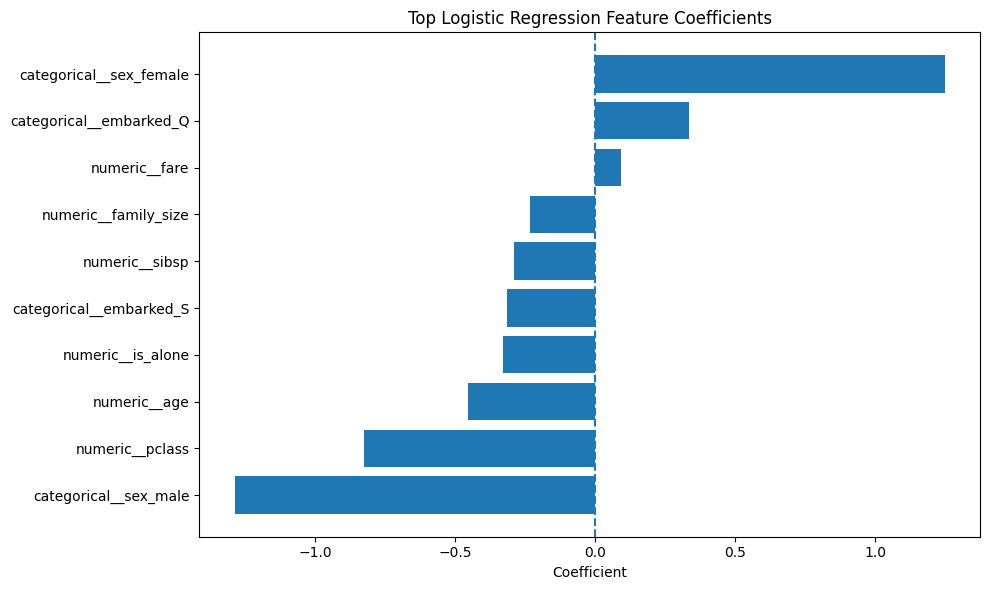

In [37]:
# ==========================================
# LOGISTIC REGRESSION COEFFICIENT PLOT
# ==========================================

top_coefficients = (
    coefficient_df
    .head(10)
    .sort_values("coefficient")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_coefficients["feature"],
    top_coefficients["coefficient"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Top Logistic Regression Feature Coefficients"
)

plt.xlabel("Coefficient")

plt.tight_layout()
plt.show()

In [38]:
# ==========================================
# SAVE FINAL CLASSIFICATION PIPELINE
# ==========================================

import joblib
import os

final_model = pipelines["Logistic Regression"]

model_path = "model_pipeline.joblib"

joblib.dump(
    final_model,
    model_path
)

print("Model saved successfully.")
print("Path:", os.path.abspath(model_path))
print("File exists:", os.path.exists(model_path))

Model saved successfully.
Path: c:\Users\nikhi\OneDrive\Desktop\zepto-data-ai-platform\analytics\model_pipeline.joblib
File exists: True


In [39]:
# ==========================================
# RELOAD SAVED PIPELINE
# ==========================================

loaded_model = joblib.load(
    "model_pipeline.joblib"
)

print(
    "Reloaded model type:",
    type(loaded_model)
)

Reloaded model type: <class 'sklearn.pipeline.Pipeline'>


In [40]:
# ==========================================
# VERIFY RELOADED MODEL
# ==========================================

loaded_predictions = loaded_model.predict(
    X_test
)

loaded_probabilities = (
    loaded_model
    .predict_proba(X_test)[:, 1]
)

print(
    "Number of predictions:",
    len(loaded_predictions)
)

print(
    "First 10 predictions:",
    loaded_predictions[:10]
)

print(
    "First 10 probabilities:",
    loaded_probabilities[:10]
)

print(
    "Reloaded model accuracy:",
    accuracy_score(
        y_test,
        loaded_predictions
    )
)

print(
    "Reloaded model ROC-AUC:",
    roc_auc_score(
        y_test,
        loaded_probabilities
    )
)

Number of predictions: 178
First 10 predictions: [0 0 0 0 0 1 0 1 1 0]
First 10 probabilities: [0.08387327 0.16168559 0.16168559 0.08877835 0.09292492 0.96106108
 0.1006757  0.89127774 0.86813727 0.08067798]
Reloaded model accuracy: 0.8202247191011236
Reloaded model ROC-AUC: 0.8649732620320855
